**1. Install & Import Dependencies**

In [ ]:
!pip install matplotlib seaborn torch torchvision tqdm scikit-learn

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

**2. Dataset Setup**

In [ ]:
data_dir = "/content/drive/MyDrive/sample"
images_dir = os.path.join(data_dir, "images")
csv_path = os.path.join(data_dir, "sample_labels.csv")

**3. Read Labels**

In [ ]:
import pandas as pd

df = pd.read_csv(csv_path)
df.head()

In [ ]:
df["FirstLabel"] = df["Finding Labels"].apply(lambda x: x.split("|")[0])
df.head()

In [ ]:
classes = sorted(df["FirstLabel"].unique())
print("Classes:", classes)

**4. Train/Validation Split**

In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["FirstLabel"])

print(len(train_df), len(val_df))

**5. Custom PyTorch Dataset**

In [ ]:
from PIL import Image

class ChestXrayDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["Image Index"])
        image = Image.open(img_path).convert("RGB")

        label = classes.index(row["FirstLabel"])

        if self.transform:
            image = self.transform(image)

        return image, label

**6. Transforms**

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

**7. Dataloaders**

In [ ]:
batch_size = 32

train_dataset = ChestXrayDataset(train_df, images_dir, train_transform)
val_dataset = ChestXrayDataset(val_df, images_dir, val_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

**8. MODEL 1: Custom CNN**

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256), nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model_cnn = SimpleCNN(num_classes=len(classes))

**9. MODEL 2: Transfer Learning (DenseNet-121)**

In [ ]:
model_tl = models.densenet121(weights="IMAGENET1K_V1")

# Freeze feature layers
for param in model_tl.features.parameters():
    param.requires_grad = False

# Replace classifier
num_features = model_tl.classifier.in_features
model_tl.classifier = nn.Linear(num_features, len(classes))

**Pick the model you want to train:**

In [ ]:
model = model_cnn  # model_tl or model_cnn

**10. Training Setup**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

**1. Training Loop**

In [ ]:
def train_model(model, train_loader, val_loader, epochs=5):
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            output = model(imgs)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))


        # Validation
        model.eval()
        val_loss = 0
        correct = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                output = model(imgs)
                val_loss += criterion(output, labels).item()
                pred = output.argmax(dim=1)
                correct += (pred == labels).sum().item()

        val_losses.append(val_loss / len(val_loader))
        accuracy = correct / len(val_loader.dataset)

        print(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f} | Val Loss={val_losses[-1]:.4f} | Val Acc={accuracy:.4f}")

    return train_losses, val_losses

**Run training:**

In [ ]:
import re

try:
    train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=5)
except FileNotFoundError as e:
    print(f"\nERROR: An image file was not found during training: {e}")
    print("Please check the following:")
    print(f"  1. Is your Google Drive mounted correctly?")
    print(f"  2. Is the 'images_dir' path correct: '{images_dir}'?")
    print("  3. Do all image files referenced in your dataset (especially the one mentioned in the error) exist in that directory?")

    # Attempt to extract the specific missing file from the error message for more specific guidance
    match = re.search(r"No such file or directory: '(.+)'", str(e))
    if match:
        problem_file = match.group(1)
        print(f"\nSpecifically, the file '{problem_file}' could not be found.")
        print("Please ensure this file is present and accessible.")

    train_losses = [] # Initialize to empty lists to avoid NameError if training didn't complete
    val_losses = []


**12. Plot Loss Curves**

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

**13. Confusion Matrix**

In [ ]:
y_true, y_pred = [], []
model.eval()

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        output = model(imgs)
        preds = (torch.sigmoid(output) > 0.5).int().cpu()

        y_true.extend(labels.numpy())
        y_pred.extend(preds.numpy())

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=classes))

**Load model from .pth file**

In [59]:
import torch

model = CustomCNN(num_classes=len(class_names))
model.load_state_dict(torch.load("/content/drive/MyDrive/sample/custom_cnn_chestxray.pth", map_location="cpu"))
model.eval()
model.to(device)

CustomCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=100352, out_features=256, bias=True)
  (drop): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=14, bias=True)
)

In [60]:
checkpoint = torch.load("/content/drive/MyDrive/sample/custom_cnn_chestxray.pth", map_location="cpu")

train_losses = checkpoint["train_losses"]
val_losses = checkpoint["val_losses"]

KeyError: 'train_losses'

In [61]:
checkpoint = torch.load("/content/drive/MyDrive/sample/custom_cnn_chestxray.pth", map_location="cpu")
layer_names = []

for layer in model.layers[:8]:
  layer_names.append(layer.name)
print(layer_names)

AttributeError: 'CustomCNN' object has no attribute 'layers'

**dataloader.py**

In [11]:
from torch.utils.data import DataLoader

def get_dataloader(dataset, batch_size=32, num_workers=2):
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)

**utils.py**

In [12]:
from torchvision import transforms
import pandas as pd
from sklearn.model_selection import train_test_split

def load_file_list(path):
    # Load a list of file names from a text file.
    with open(path, "r") as f:
        return [line.strip() for line in f.readlines()]

def split_dataset(csv, val_size=0.15, test_size=0.15, random_state=42):
    df = pd.read_csv(csv)

    # Split dataset into training and validation sets.
    train_val_df, test_df = train_test_split(df, test_size=test_size, random_state=random_state, shuffle=True)
    # Adjust validation size relative to training set.
    val_size = val_size / (1 - test_size)
    # Split train_val_set into training and validation sets.
    train_df, val_df = train_test_split(train_val_df, test_size=val_size, random_state=random_state, shuffle=True)
    return train_df, val_df, test_df

def compute_mean_std(df, img_dir, transform=None, class_names=None):
    # Compute the mean and standard deviation of a dataset.
    if transform is None:
        transform = transforms.ToTensor()

    dataset = ChestXrayDataset(df, img_dir, transform=transform, class_names=class_names)
    loader = get_dataloader(dataset)
    mean = 0.0
    std = 0.0
    total_samples = 0

    for images, _ in loader:
        batch_samples = images.size(0)
        images = images.view(batch_samples, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total_samples += batch_samples

    mean /= total_samples
    std /= total_samples
    return mean.numpy(), std.numpy()

**preprocess.py**

In [13]:
from torchvision import transforms

def get_transforms(mean, std, train=True):
    # Transform images in training dataset.
    if train:
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),  # Add augmentation to prevent overfitting.
            transforms.RandomRotation(10),
             transforms.RandomAffine(
                degrees=10,
                translate=(0.05, 0.05),
                scale=(0.95, 1.05)
            ),
            transforms.ColorJitter(
                brightness=0.1,
                contrast=0.1
            ),
            transforms.ToTensor(),  # Convert PIL image to PyTorch tensor.
            transforms.Normalize(mean=mean, std=std)  # Normalize for ImageNet pre-training data.
        ])
    # Transform images in validation/test dataset.
    else:
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

**cnn.py**

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomCNN(nn.Module):
    def __init__(self, num_classes, in_channels=3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        # after 3 poolings, spatial dims reduced by 8x: assume input 224 -> ~28
        self.fc1 = nn.Linear(128 * 28 * 28, 256)
        self.drop = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)  # num_classes logits

        # initialize
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)   # logit
        return x


**loss.py**

In [15]:
import torch.nn as nn

def get_loss_function():
    return nn.BCEWithLogitsLoss()

**evaluate.py**

In [16]:
def evaluate_model(model, dataloader, device, loss_fn):
    model.eval()
    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            labels = labels.to(device).float()
            logits = model(imgs)
            loss = loss_fn(logits, labels)
            total_loss += loss.item() * imgs.size(0)

            preds = (torch.sigmoid(logits) > 0.5).float()
            correct_predictions += (preds == labels).sum().item()
            total_samples += imgs.size(0)

    avg_loss = total_loss / total_samples
    accuracy = correct_predictions / (total_samples * labels.size(1))

    return avg_loss, accuracy

**dataset.py**

In [20]:
import os
from PIL import Image
from torch.utils.data import Dataset

class ChestXrayDataset(Dataset):
    def __init__(self, df, img_dir, transform, class_names):
        """
        Args:
            df: DataFrame containing image filenames and labels.
            img_dir: Directory with all the images.
            transform: Transformations to apply to the images.
            class_names: List of class names for multi-label classification.
            file_list: Path to a text file containing the list of image filenames to include.
        """
        self.data = df.reset_index(drop=True)  # Reset the splitted DataFrame index to start from 0.
        self.img_dir = img_dir
        self.transform = transform
        self.class_names = class_names

        # Convert multi-label strings into binary columns for each class
        for label in self.class_names:
            self.data[label] = self.data["Finding Labels"].apply(lambda x: 1.0 if label in x else 0.0)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, self.data.iloc[idx, 0])  # Fetch the image's name of index idx from CSV.
        image = Image.open(img_name).convert("RGB")  # Convert to RGB for ImageNet compatibility.

        # Extract the 14*1 label array for each image, and convert labels to float32.
        labels = self.data[self.class_names].iloc[idx].values.astype("float32")

        if self.transform:
            image = self.transform(image)

        return image, labels

**train.py**

In [56]:
def compute_accuracy(logits, labels):
    # For multi-label classification, apply sigmoid and a threshold
    preds = (torch.sigmoid(logits) > 0.5).float()
    # Compare the predicted multi-hot labels with the true multi-hot labels
    correct = (preds == labels).sum().item()
    # The total number of comparisons is batch_size * num_classes
    total = labels.numel() # number of elements in the labels tensor
    return correct, total

def train_model(model, train_loader, val_loader, loss_fn, optimizer, num_epochs, device, scaler=None, save_path="checkpoint.pth"):
    """
    Trains the model for a specified number of epochs and validates it after each epoch.

    Args:
        model: The PyTorch model to train.
        train_loader: DataLoader for the training dataset.
        val_loader: DataLoader for the validation dataset.
        loss_fn: Loss function to use.
        optimizer: Optimizer for updating model parameters.
        num_epochs: Number of epochs to train for.
        device: Device to train on (e.g., 'cuda' or 'cpu').
        scaler: Optional GradScaler for mixed precision training.

    Returns:
        A dictionary containing training and validation losses for each epoch.
    """
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")

        # Train for one epoch
        train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device, scaler)
        history["train_loss"].append(train_loss)

        # Validate the model
        model.eval()
        val_loss = 0.0
        correct_total = 0
        total_samples = 0

        with torch.no_grad():
            for imgs, labels_multi in val_loader:
                imgs = imgs.to(device)
                labels_multi = labels_multi.to(device).float()  # Ensure labels are on the same device and in float format
                logits = model(imgs)
                loss = loss_fn(logits, labels_multi)
                val_loss += loss.item() * imgs.size(0)

                correct, total = compute_accuracy(logits, labels_multi) # Pass labels_multi
                correct_total += correct
                total_samples += total

        val_loss /= len(val_loader.dataset)
        # Calculate overall accuracy for validation set
        val_acc = correct_total / total_samples
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        # Save checkpoint every epoch
        checkpoint = {
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "train_loss": history["train_loss"],
            "val_loss": history["val_loss"],
            "num_epochs": epoch + 1
        }

        torch.save(checkpoint, save_path)
        print(f"Checkpoint saved → {save_path}")

    return history

def train_one_epoch(model, loader, criterion, optimizer, device, scaler=None):
    model.train()
    running_loss = 0.0
    correct_total = 0
    total_samples = 0

    for imgs, labels_multi in tqdm(loader, desc="train", leave=False):
        imgs = imgs.to(device)
        labels_multi = labels_multi.to(device).float()  # Ensure labels are on the same device and in float format.

        with torch.amp.autocast(device_type="cuda", enabled=(scaler is not None)):  # Updated for deprecation warning.
            logits = model(imgs)  # Raw model output for one batch
            loss = criterion(logits, labels_multi)  # Compute loss.

        optimizer.zero_grad()

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * imgs.size(0)

        # compute accuracy
        correct, total = compute_accuracy(logits, labels_multi) # Pass labels_multi
        correct_total += correct
        total_samples += total

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct_total / total_samples

    return epoch_loss, epoch_acc

**Main.py**

In [57]:
data_dir = "/content/drive/MyDrive/sample"
img_dir = os.path.join(data_dir, "images")
data_csv = os.path.join(data_dir, "sample_labels.csv")
num_epochs = 10
batch_size = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available, else CPU
lr = 1e-4  # Learning rate for optimizer

# Class names for multi-label classification
class_names = [
"Atelectasis", "Cardiomegaly", "Effusion", "Infiltration",
"Mass", "Nodule", "Pneumonia", "Pneumothorax",
"Consolidation", "Edema", "Emphysema", "Fibrosis",
"Pleural_Thickening", "Hernia"
]

## train_val_list = load_file_list(train_val_files)
train_df, val_df, test_df = split_dataset(data_csv, val_size=0.15, test_size=0.15, random_state=42)

mean, std = compute_mean_std(train_df, img_dir, class_names=class_names)

# Get transforms for training and validation
train_transforms = get_transforms(mean, std, train=True)  # Applies augmentation for training
val_transforms = get_transforms(mean, std, train=False)  # No augmentation for validation

# Create datasets, filtering by file lists
train_dataset = ChestXrayDataset(train_df, img_dir, train_transforms, class_names)
val_dataset = ChestXrayDataset(val_df, img_dir, val_transforms, class_names)
test_dataset = ChestXrayDataset(test_df, img_dir, val_transforms, class_names)

    # Create DataLoaders for batching
train_loader = get_dataloader(train_dataset, batch_size=batch_size, num_workers=2)  # Shuffles and batches training data
val_loader = get_dataloader(val_dataset, batch_size=batch_size, num_workers=2)  # Batches validation data without shuffling
test_loader = get_dataloader(test_dataset, batch_size=batch_size, num_workers=2)  # Batches test data without shuffling

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")

# Get model, loss function, and optimizer
model = CustomCNN(num_classes=len(class_names))
model = model.to(device)
loss_fn = get_loss_function()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

print("Starting training...")
# Train the model
train_losses, val_losses = train_model(model, train_loader, val_loader, loss_fn, optimizer, num_epochs, device)  # Trains for num_epochs

print("Training complete!")

test_loss, test_acc = evaluate_model(model, test_loader, device, loss_fn)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

Number of training samples: 3924
Number of validation samples: 841
Starting training...
Epoch 1/10


KeyboardInterrupt: 

In [ ]:
torch.save(model.state_dict(), "src/models/custom_cnn_chestxray.pth")

In [33]:
train_losses = [0.3439, 0.2593, 0.2430, 0.2454, 0.2323, 0.2245, 0.2241, 0.2189, 0.2166, 0.2181]
val_losses   = [0.2040, 0.2166, 0.2308, 0.2454, 0.1989, 0.2146, 0.2074, 0.2165, 0.2050, 0.2038]

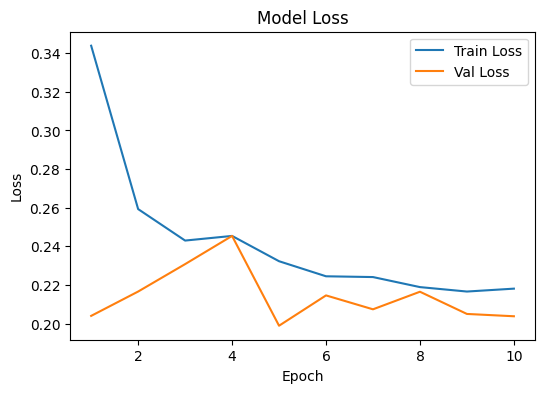

In [44]:
plt.figure(figsize=(6,4))
epochs = range(1, len(train_losses) + 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.legend()
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [45]:
y_true, y_pred = [], []
model.eval()

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        output = model(imgs)
        preds = output.argmax(dim=1).cpu()

        y_true.extend(labels.numpy())
        y_pred.extend(preds.numpy())

In [58]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=classes))

ValueError: Classification metrics can't handle a mix of multilabel-indicator and multiclass targets